In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

As mentioned before, when a trading demand arrives, we don't need to trade immediately. Instead, we can place a limited order at a better price. The problem is how to choose the better price.

We use filling probability. But market's regime changes overtime, it's better to identify the current regime and then calculate the filling probability conditional on this regime.

How to identify the regime. Under the instruction of project PDF file, we define some state variables, and use them to identify regimes.

Looking at the data, we have 3 kinds of information: time, price, and volume.

1. Time & Volume: The reason whe discuss these two together is that: they are highly related. There are 23 trading hours per trading day. But only 9:30AM-4:00PM is the common trading period with high volume, the volume of other hours is significantly low. So, my idea is, we can use volume, or exponential moving average of volume, as one state variable. It not only reflects the change of volume, but also indirectly indicates the trading time.

2. Price (trend): It's natural to get trend information from price data. If the price continue to rise, there is a upward trend, vice versa. The key is how to use price data to design a state variale that can reflect the trend. We choose to use the gap between short and long term exponential price average. If short > long, it indicates an upward trend; if short < long, it indicates a downward trend. This is not the best choice to identify trend state, but it's easy to understand.

3. Price (volatility): Apart from the trend, price only contains volatility information. And we think this should be the most important state variale. Because if volatility is large, the price flucuation will probably be large in the future, the high price will be higher, and the low price will be lower. The filling probability of choose a large k(number of tick size) is higher. Also, there are many ways to define volatiltity, we choose the most commonly used one: volatility in t minutes is the sum of square of t 1-minute returns.

In the folling parts, we study these state variables.

# **Volume & Trading Hours**

We plot the average trading volume for each trading hour during the preparation period (becasue we can't look ahead, we don't know trading part yet). But we need to use agent data to know at which hour the agent trades. The red bars indicates the volume of hours at which agent has trading demand, while blue bars don't.

We can see that agent trades not only during the normal trading period, but also before and after it. So we can't just remain data in the normal trading period and delete other parts.

Also, we see that time and volume are indeed related. The volume during the normal trading period is significantly higher than that of the abnormal trading period. So it make sense to use volme as a state variable to represent both volume and time. This also solves the curse of dimension. Because if we also use time as a state variable, time itself will have lots of level (e.g. if we use hour to seperate, there are 23 hours), if these level multiply the combination of other variables, the dimension will be quite large.

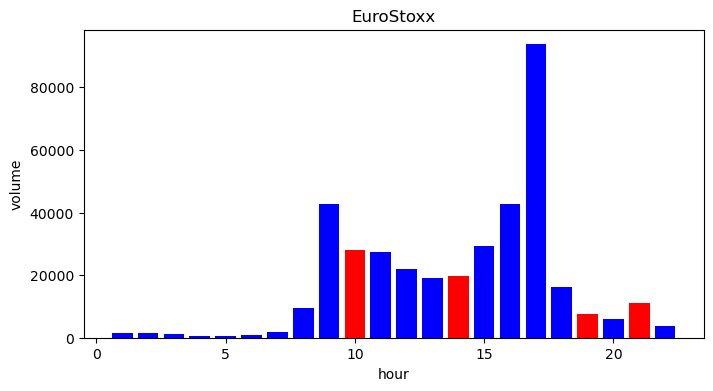

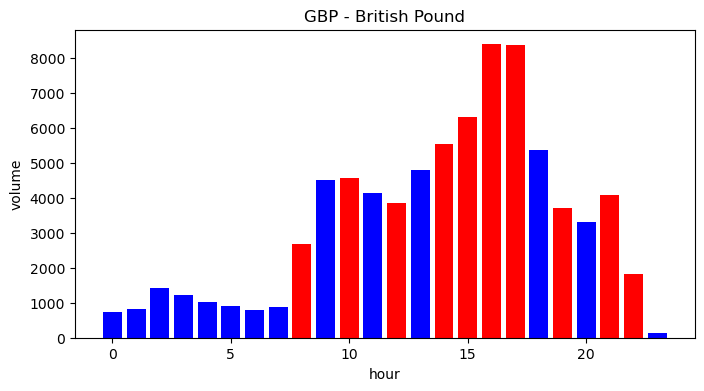

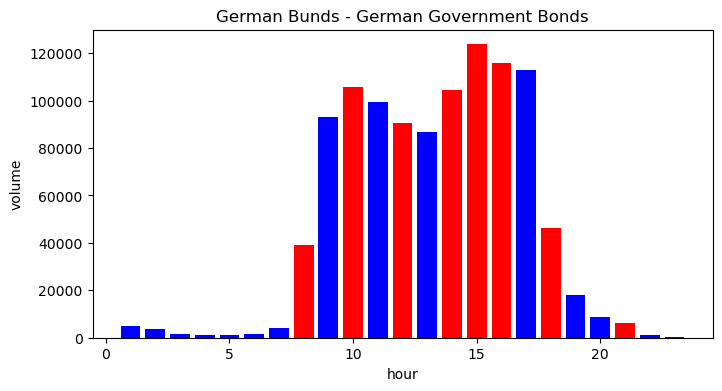

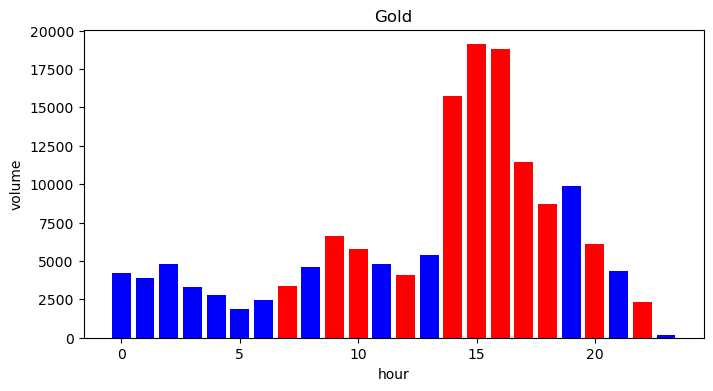

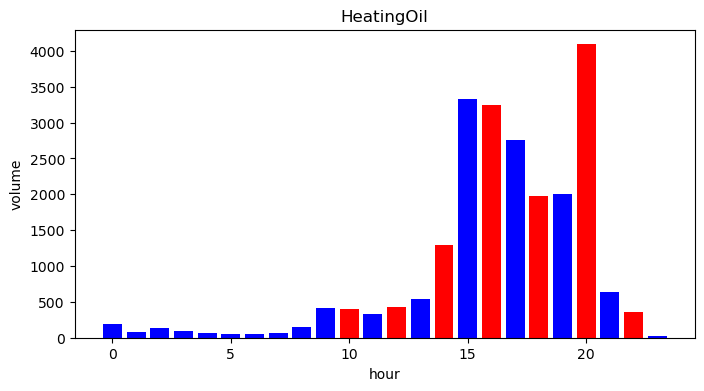

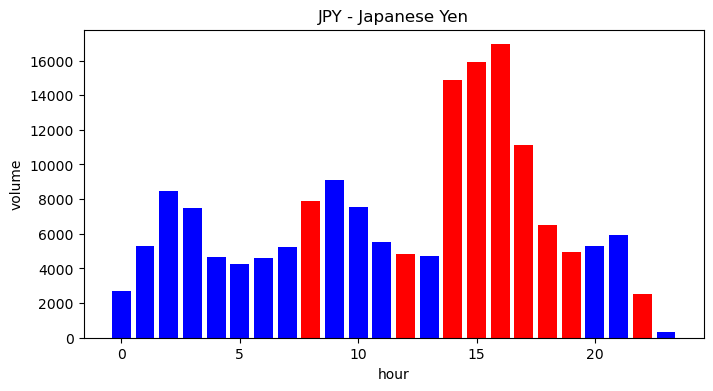

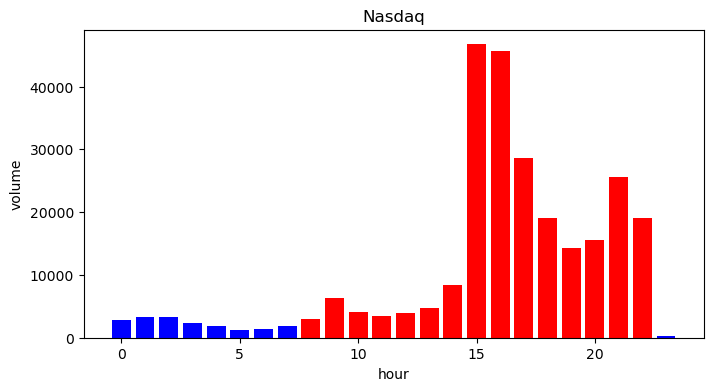

In [2]:
raw_data_path=RAW_DATA_DIR
futures_path=DATA_DIR/'futures_right'
agent_path=DATA_DIR/'agent_right'

column_list=['time','open','high','low','close','volume']
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
for market in markets:
    data1_prep=pd.read_parquet(futures_path/'minute_1'/f'{market}_prep.parquet').reset_index(drop=True)
    data5_prep=pd.read_parquet(futures_path/'minute_5'/f'{market}_prep.parquet').reset_index(drop=True)
    data1_prep=data1_prep[column_list]
    data5_prep=data5_prep[column_list]
    agent_data=pd.read_parquet(agent_path/f'{market}.parquet').reset_index(drop=True)
    
    # analysis
    data5_prep['hour']=(data5_prep['time'].dt.hour).astype(int)
    data5_prep['date']=data5_prep['time'].dt.date
    data_hour=data5_prep.groupby(['date','hour'])['volume'].sum().reset_index()
    data_hour=data_hour.groupby('hour')['volume'].mean().reset_index()
    
    agent_data['trade']=agent_data['position'].diff().fillna(0)
    red_list=sorted(agent_data[agent_data['trade']!=0]['hour'].unique().tolist())

    # plot
    colors = ['red' if h in red_list else 'blue' for h in data_hour['hour']]
    plt.figure(figsize=(8,4))
    plt.bar(data_hour['hour'],data_hour['volume'], color=colors)
    plt.xlabel('hour')
    plt.ylabel('volume')
    plt.title(f'{market}')
    plt.show()

# **Price: Volatility + Trend**

I constructed several features about volatility and trend:

first set tau=5, this means the trading frequency, 5-minute is the default choice

1. volatility: sum of square of 1-minute return during the tau-minute horizon

2. high_minus_previous_close: hight price in the current tau interval minus the close price of the last interval

3. previous_close_minus_low: close price of the last interval minus the low price in the current interval

4. crossover: short term exponential moving close price average minus long term exponential moving close price average

5. volume: the volume of the current interval (this is not a feature of volatility or trend, but we contruct it to compare with other feautures).

We didn't mention high_minus_previous_close and previous_close_minus_low before, why do we calculate them here? Think about what we predict. We want to know the filling probability. When placing buy order, we care about high_minus_previous_close; when placing sell order, we care about previous_close_minus_low. So a straightforward thinking is that: previous smoothed values may have predictive power on future values. This the reason why we also constructed these two features there.

Then calculate the exponential moving average of all these features.

Note: there are parameters to choose for contructing features and smooth them:

1. tau: choose the trading freqency and forward looking time length

2. window length of short/long term exponential moving average

3. the span length of exponential moving average, you can choose same value for all features, but you can also choose different values for different features.

We choose a set of default parameters, which is based on experience and tuition.

In [57]:
def sparse_ema(series: pd.Series, step: int, span: int) -> pd.Series:
    """
    EWMA over non-overlapping tau-interval points.

    Important:
    - span is interpreted as half-life m
    - lambda = 2 ** (-1 / m)
    - EWMA at time j uses observations up to j-1, not current j
    """
    values = series.to_numpy(dtype=float)
    out = np.full(len(series), np.nan, dtype=float)

    lam = 2.0 ** (-1.0 / span)

    for offset in range(step):
        idx = np.arange(offset, len(series), step)
        sub = values[idx]

        sumW = 0.0
        sumWX = 0.0

        for j, x in enumerate(sub):
            # current EWMA uses past observations only
            if sumW > 0:
                out[idx[j]] = sumWX / sumW
            else:
                out[idx[j]] = 0.0

            # update using current x for future timestamps
            if not np.isnan(x):
                sumW = lam * sumW + 1.0
                sumWX = lam * sumWX + x
            else:
                sumW = lam * sumW
                sumWX = lam * sumWX

    return pd.Series(out, index=series.index)


def build_tau_features(
    data1: pd.DataFrame,
    data5: pd.DataFrame,
    tau: int = 10,
    ema_spans: dict | None = None,
    use_log_return: bool = True,
) -> pd.DataFrame:
    """
    data1: 1-minute OHLCV dataframe
    data5: 5-minute OHLCV dataframe
    columns in both: ['time', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data5 indexed features, where each row corresponds to one timestamp in data5.
        The tau-minute interval is assumed to END at that timestamp.
        
    ema_spans:
        Dictionary controlling the EMA span of each feature separately.
        Example:
        ema_spans = {
            "volume_t": 100,
            "high_minus_prev_close": 50,
            "prev_close_minus_low": 50,
            "close_diff": 30,
            "volatility_t": 100,
            "price_short": 20,
            "price_long": 100,
        }
    """

    if tau % 5 != 0:
        raise ValueError("tau must be a multiple of 5 because data5 is 5-minute frequency.")
    n5 = tau // 5
    
    if ema_spans is None:
        ema_spans = {
            "volume_t": 100,
            "high_minus_prev_close": 100,
            "prev_close_minus_low": 100,
            "close_diff": 100,
            "volatility_t": 100,
            "price_short": 20,
            "price_long": 100,
        }

    # Copy and sort
    data1 = data1.copy()
    data5 = data5.copy()
    data1["time"] = pd.to_datetime(data1["time"])
    data5["time"] = pd.to_datetime(data5["time"])
    data1 = data1.sort_values("time").set_index("time")
    data5 = data5.sort_values("time").set_index("time")

    # Tau-minute OHLCV from rolling window on 5-minute bars
    feat = pd.DataFrame(index=data5.index)
    feat["volume_t"] = data5["volume"].rolling(n5).sum()
    feat["high_t"] = data5["high"].rolling(n5).max()
    feat["low_t"] = data5["low"].rolling(n5).min()
    feat["close_t"] = data5["close"]
    feat["volume_t_minus_1"] = feat["volume_t"].shift(n5)
    feat["close_t_minus_1"] = feat["close_t"].shift(n5)

    # 1. volume(t)
    feat["ema_volume_t"] = sparse_ema(feat["volume_t"], step=n5, 
                                      span=ema_spans.get("volume_t", 100))
    
    # 2. high(t)-close(t-1)
    feat["high_minus_prev_close"] = feat["high_t"] - feat["close_t_minus_1"]
    feat["ema_high_minus_prev_close"] = sparse_ema(feat["high_minus_prev_close"], step=n5, 
                                                   span=ema_spans.get("high_minus_prev_close", 100))

    # 3. close(t-1)-low(t)
    feat["prev_close_minus_low"] = feat["close_t_minus_1"] - feat["low_t"]
    feat["ema_prev_close_minus_low"] = sparse_ema(feat["prev_close_minus_low"], step=n5, 
                                                  span=ema_spans.get("prev_close_minus_low", 100))

    # 4. close(t)-close(t-1)
    feat["close_diff"] = feat["close_t"] - feat["close_t_minus_1"]
    feat["ema_close_diff"] = sparse_ema(feat["close_diff"], step=n5, 
                                        span=ema_spans.get("close_diff", 100))

    # 5. volatility (t)
    if use_log_return:
        r1 = np.log(data1["close"]).diff()
    else:
        r1 = data1["close"].pct_change()
    vol_1m = np.sqrt((r1 ** 2).rolling(tau).sum()*(252*24*60/tau))
    feat["volatility_t"] = vol_1m.reindex(feat.index)
    feat["ema_volatility_t"] = sparse_ema(feat["volatility_t"], step=n5, 
                                          span=ema_spans.get("volatility_t", 100))
    
    # 6. Price EMA features
    feat["ema_price_short"] = sparse_ema(feat["close_t"],step=n5,
                                         span=ema_spans.get("price_short", 20))
    feat["ema_price_long"] = sparse_ema(feat["close_t"],step=n5,
                                        span=ema_spans.get("price_long", 100))
    feat["ema_price_diff"] = feat["ema_price_short"] - feat["ema_price_long"]
    feat["ema_price_diff_pct"] = feat["ema_price_diff"] / feat["close_t"]*100

    return feat.reset_index()


In [58]:
futures_path=DATA_DIR/'futures_right'
agent_path=DATA_DIR/'agent_right'
market='Nasdaq'

data1_prep=pd.read_parquet(futures_path/'minute_1'/f'{market}_prep.parquet').reset_index(drop=True)
data5_prep=pd.read_parquet(futures_path/'minute_5'/f'{market}_prep.parquet').reset_index(drop=True)
agent_data=pd.read_parquet(agent_path/f'{market}.parquet').reset_index(drop=True)

column_list=['time','open','high','low','close','volume']
data1_prep=data1_prep[column_list]
data5_prep=data5_prep[column_list]

In [66]:
ema_spans = {
    "volume_t": 100,
    "high_minus_prev_close": 100,
    "prev_close_minus_low": 100,
    "close_diff": 100,
    "volatility_t": 100,
    "price_short": 20,
    "price_long": 100,

}

tau=5
n_bar=tau//5

features = build_tau_features(data1_prep, data5_prep, tau=tau, ema_spans=ema_spans)
features['target_high']=features['high_minus_prev_close'].shift(-n_bar)
features['target_low']=features['prev_close_minus_low'].shift(-n_bar)
print(features.columns)
features.tail()

Index(['time', 'volume_t', 'high_t', 'low_t', 'close_t', 'volume_t_minus_1',
       'close_t_minus_1', 'ema_volume_t', 'high_minus_prev_close',
       'ema_high_minus_prev_close', 'prev_close_minus_low',
       'ema_prev_close_minus_low', 'close_diff', 'ema_close_diff',
       'volatility_t', 'ema_volatility_t', 'ema_price_short', 'ema_price_long',
       'ema_price_diff', 'ema_price_diff_pct', 'target_high', 'target_low'],
      dtype='object')


,time,volume_t,high_t,low_t,close_t,volume_t_minus_1,close_t_minus_1,ema_volume_t,high_minus_prev_close,ema_high_minus_prev_close,...,close_diff,ema_close_diff,volatility_t,ema_volatility_t,ema_price_short,ema_price_long,ema_price_diff,ema_price_diff_pct,target_high,target_low
3311,2020-01-02 05:35:00,58.0,8789.75,8788.75,8789.75,63.0,8788.75,1070.101274,1.00,1.946727,...,1.00,0.229674,0.020274,0.069588,8781.207478,8755.729779,25.477699,0.289857,0.25,0.25
3312,2020-01-02 05:40:00,43.0,8790.00,8789.50,8789.75,58.0,8789.75,1063.110180,0.25,1.940187,...,0.00,0.234995,0.013272,0.069244,8781.498467,8755.964773,25.533694,0.290494,0.00,1.25
3313,2020-01-02 05:45:00,63.0,8789.75,8788.50,8789.50,43.0,8789.75,1056.063764,0.00,1.928512,...,-0.25,0.233372,0.044020,0.068854,8781.779545,8756.198145,25.581400,0.291045,-0.25,1.00
3314,2020-01-02 05:50:00,35.0,8789.25,8788.50,8789.00,63.0,8789.50,1049.204172,-0.25,1.915191,...,-0.50,0.230033,0.026546,0.068680,8782.042532,8756.428178,25.614354,0.291437,0.25,2.00
3315,2020-01-02 05:55:00,218.0,8789.25,8787.00,8787.50,35.0,8789.00,1042.198552,0.25,1.900235,...,-1.50,0.224990,0.032515,0.068387,8782.279529,8756.653168,25.626361,0.291623,NaN,NaN


In [67]:
feature_columns=['ema_volume_t','ema_high_minus_prev_close','ema_prev_close_minus_low','ema_volatility_t','ema_price_diff_pct']

print('feature correlation:')
features[feature_columns].corr().round(3)

feature correlation:


,ema_volume_t,ema_high_minus_prev_close,ema_prev_close_minus_low,ema_volatility_t,ema_price_diff_pct
ema_volume_t,1.000,0.618,0.754,0.674,-0.283
ema_high_minus_prev_close,0.618,1.000,0.891,0.963,-0.242
ema_prev_close_minus_low,0.754,0.891,1.000,0.961,-0.470
ema_volatility_t,0.674,0.963,0.961,1.000,-0.363
ema_price_diff_pct,-0.283,-0.242,-0.470,-0.363,1.000


From the correlation matrix we can see that: 

- volatility has high correlation with high_minus_previous_close and previous_close_minus_low. So, we can only choose volatility as the state variable, it represents volatility itself, also high_minus_previous_close and previous_close_minus_low.

-  volatility has relatively low correlation with volume, this indicates that volume can also be a state variable, which is natural since we already show that volume differs a lot in different time.

- volatility has negative correlation with trend indicator: crossover, or ema_price_diff_pct in my code. This meets our knowledge, because voaltility has leverage effect in equity market. So trend can also be a state variable.

In [68]:
print('correlation between features and target:')

for c in feature_columns:
    print(f'{c}:')
    print(f'high: {features[c].corr(features['target_high']).round(3)}')
    print(f'low: {features[c].corr(features['target_low']).round(3)}')
    print()

correlation between features and target:
ema_volume_t:
high: 0.121
low: 0.075

ema_high_minus_prev_close:
high: 0.204
low: 0.154

ema_prev_close_minus_low:
high: 0.263
low: 0.21

ema_volatility_t:
high: 0.237
low: 0.182

ema_price_diff_pct:
high: -0.149
low: -0.136



Here we calcualted the predictive power of these smoothed features. Few results are worth noticing:

- The predictive power for high_minus_previous_low (used when we place sell order) is higher than that for previous_close_minus_low (used when we place buy order). We don't know the reason yet.

- The predictive power of volatility and high_minus_previous_low, previous_close_minus_low is very close. This is because they are highly correlated.

- volume and trend have weaker predictive power, and trend has reverse predictive power.

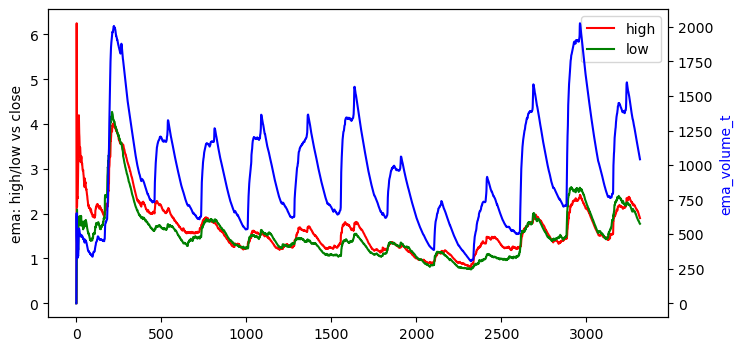

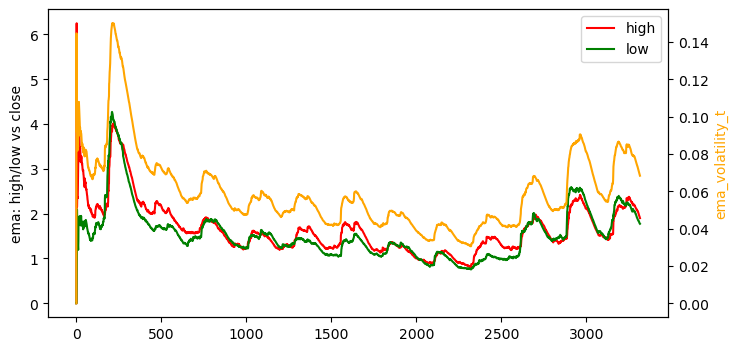

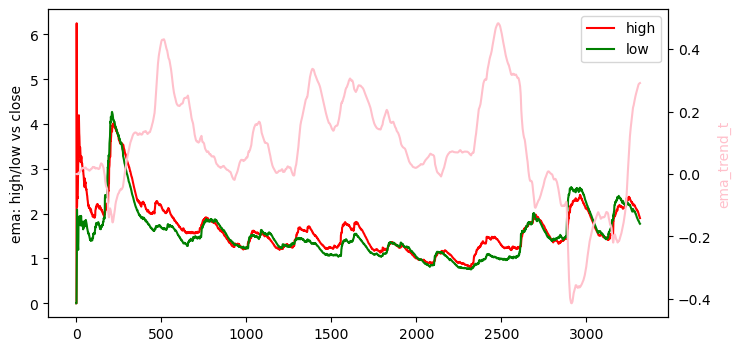

In [62]:
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(features.index,features['ema_high_minus_prev_close'],color='red',label='high')
ax.plot(features.index,features['ema_prev_close_minus_low'],color='green',label='low')
ax.set_ylabel('ema: high/low vs close',color='black')
ax.legend()
ax2=ax.twinx()
ax2.plot(features.index,features['ema_volume_t'],color='blue',label='volume')
ax2.set_ylabel('ema_volume_t',color='blue')
plt.show()

fig,ax=plt.subplots(figsize=(8,4))
ax.plot(features.index,features['ema_high_minus_prev_close'],color='red',label='high')
ax.plot(features.index,features['ema_prev_close_minus_low'],color='green',label='low')
ax.set_ylabel('ema: high/low vs close',color='black')
ax.legend()
ax2=ax.twinx()
ax2.plot(features.index,features['ema_volatility_t'],color='orange',label='vol')
ax2.set_ylabel('ema_volatility_t',color='orange')
plt.show()

fig,ax=plt.subplots(figsize=(8,4))
ax.plot(features.index,features['ema_high_minus_prev_close'],color='red',label='high')
ax.plot(features.index,features['ema_prev_close_minus_low'],color='green',label='low')
ax.set_ylabel('ema: high/low vs close',color='black')
ax.legend()
ax2=ax.twinx()
ax2.plot(features.index,features['ema_price_diff_pct'],color='pink',label='trend')
ax2.set_ylabel('ema_trend_t',color='pink')
plt.show()

# **Conditional Filling Probability**

Now we have 3 state variables: volatility, volume, and trend. Then how to divide them effectively and also avoid the curse of high dimension?

My idea is to seperate volatility and trend into 3 equal parts using 1/3 and 2/3 quantiles. But for volume, we use different method. Look at the time and volume plots in the first part of this file. We see that about 1/3 parts of the time is commonly trading time, the resting 2/3 time has low volume. So we use 2/3 quantile to seperate data into two parts.

We first exam volatilty and volume combination, as in the last part, volatility and volume as correlation around 0.6. Although it's much lower than the correlation among volatility, high_minus_previous_close, and previous_close_minus_low, the value is still a bit high.

In [63]:
def make_survival_curve(
    x: pd.Series,
    tick_size: float = 0.25,
    max_k: int = 10,
) -> pd.DataFrame:
    """
    Compute P(X >= k ticks), for k = 0, 1, ..., max_k.

    Example:
    If x is target_low, this gives:
        P(target_low >= k ticks)

    If x is target_high, this gives:
        P(target_high >= k ticks)
    """

    x = x.dropna().copy()

    k = x / tick_size
    k = np.where(k < 0, 0, k)

    # CHANGE:
    # Round to integer tick units to avoid floating-point noise.
    k = np.round(k).astype(int)

    grid = np.arange(0, max_k + 1)

    out = pd.DataFrame({"k": grid})
    out["p"] = [(k >= kk).mean() for kk in grid]

    return out

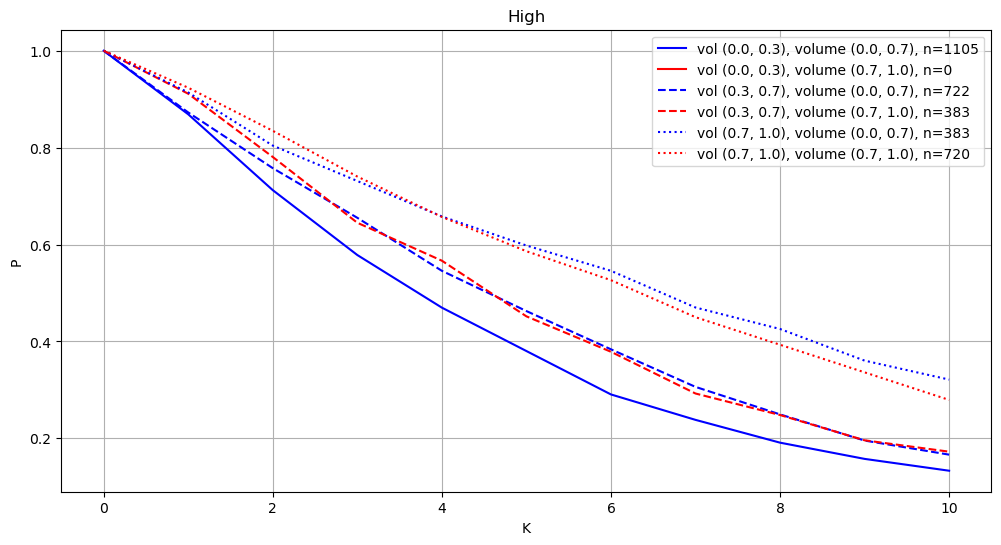

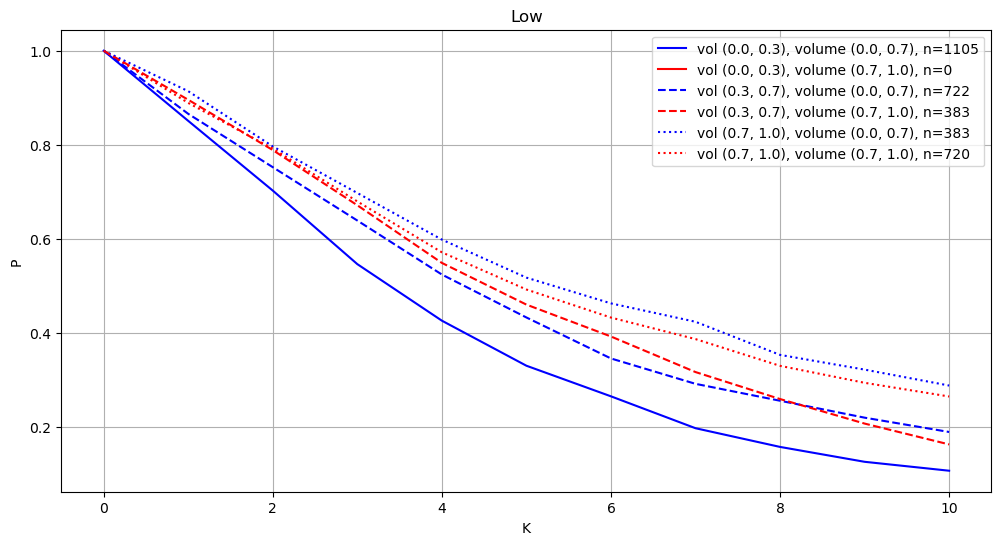

In [64]:
temp=features.dropna(subset=['ema_volatility_t','ema_volume_t','target_high','target_low']).copy()

num_cuts=3
volatility_cuts=[(float(i)/num_cuts,float(i+1)/num_cuts) for i in range(num_cuts)]
trend_cuts=[(float(i)/num_cuts,float(i+1)/num_cuts) for i in range(num_cuts)]
volume_cuts=[(0.0,2.0/3.0),(2.0/3.0,1.0)] # correponding to time
tick_size=0.25
max_k = 10

result_dict={}
for vol_c in volatility_cuts:
    for volume_c in volume_cuts:
        vol_q=temp['ema_volatility_t'].quantile([vol_c[0],vol_c[1]]).values.tolist()
        volume_q=temp['ema_volume_t'].quantile([volume_c[0],volume_c[1]]).values.tolist()

        vv_temp=temp[(temp['ema_volatility_t']>=vol_q[0])&
                     (temp['ema_volatility_t']<vol_q[1])&
                     (temp['ema_volume_t']>=volume_q[0])&
                     (temp['ema_volume_t']<volume_q[1])]
        
        high_curve = make_survival_curve(
            vv_temp["target_high"],
            tick_size=tick_size,
            max_k=max_k,
        )

        low_curve = make_survival_curve(
            vv_temp["target_low"],
            tick_size=tick_size,
            max_k=max_k,
        )

        key = (
            round(vol_c[0], 1),
            round(vol_c[1], 1),
            round(volume_c[0], 1),
            round(volume_c[1], 1),
        )

        result_dict[key] = {
            "high": high_curve,
            "low": low_curve,
            "n_obs": len(vv_temp),
        }


vol_linestyle = {
    (0.0, 0.3): "-",
    (0.3, 0.7): "--",
    (0.7, 1.0): ":",
}
volume_color = {
    (0.0, 0.7): "blue",
    (0.7, 1.0): "red",
}

plt.figure(figsize=(12,6))
for key,obj in result_dict.items():
    vol_key = (key[0], key[1])
    volume_key = (key[2], key[3])
    df = obj["high"]
    plt.plot(df['k'],df['p'],
             linestyle=vol_linestyle.get(vol_key, "-"),
             color=volume_color.get(volume_key, "black"),
             label=f"vol {vol_key}, volume {volume_key}, n={obj['n_obs']}")
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('P')
plt.title('High')
plt.show()



plt.figure(figsize=(12,6))
for key,obj in result_dict.items():
    vol_key = (key[0], key[1])
    volume_key = (key[2], key[3])
    df = obj["low"]
    plt.plot(df['k'],df['p'],
             linestyle=vol_linestyle.get(vol_key, "-"),
             color=volume_color.get(volume_key, "black"),
             label=f"vol {vol_key}, volume {volume_key}, n={obj['n_obs']}")
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('P')
plt.title('Low')
plt.show()

From the plot we see that, within same volatility parts, volume doesn't have seperating power. So we believe that volatility also contains volume information. 

Now there are only two state variables remaing: volatility and trend. We construct 3*3 grids and calulate conditional filling probabolities.

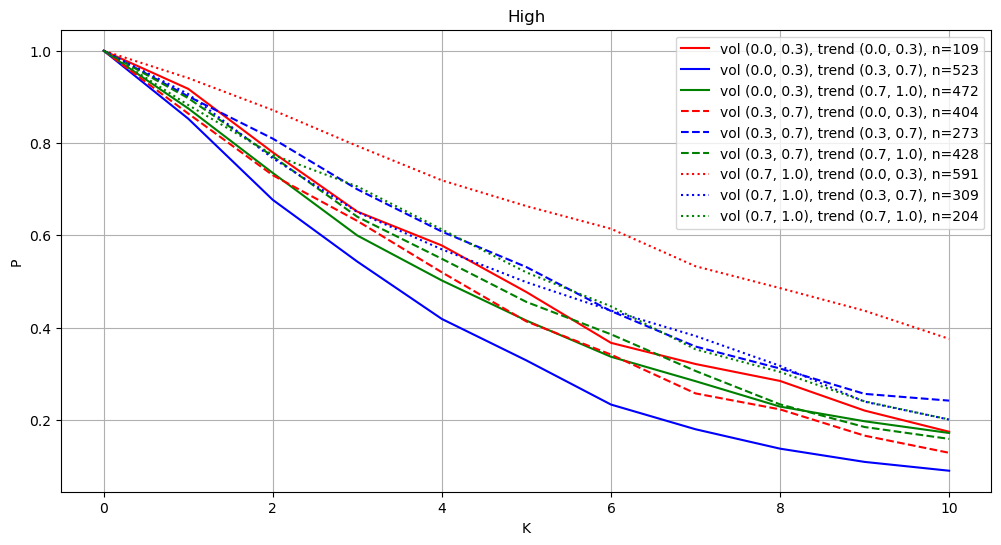

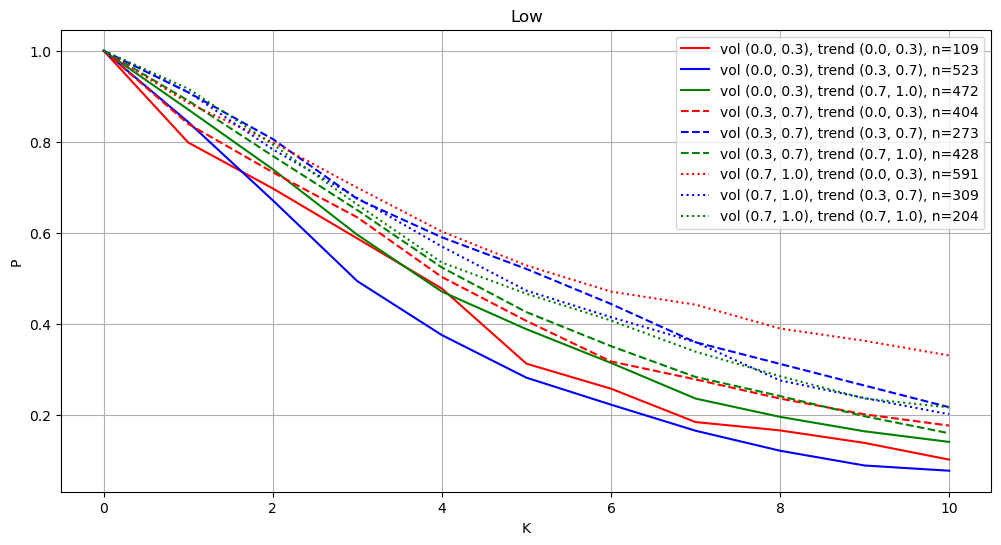

In [65]:
temp=features.dropna(subset=['ema_volatility_t','ema_price_diff_pct','target_high','target_low']).copy()

num_cuts=3
volatility_cuts=[(float(i)/num_cuts,float(i+1)/num_cuts) for i in range(num_cuts)]
trend_cuts=[(float(i)/num_cuts,float(i+1)/num_cuts) for i in range(num_cuts)]
tick_size=0.25
max_k=10

result_dict={}
for vol_c in volatility_cuts:
    for trend_c in trend_cuts:
        vol_q=temp['ema_volatility_t'].quantile([vol_c[0],vol_c[1]]).values.tolist()
        trend_q=temp['ema_price_diff_pct'].quantile([trend_c[0],trend_c[1]]).values.tolist()

        vv_temp=temp[(temp['ema_volatility_t']>=vol_q[0])&
                    (temp['ema_volatility_t']<vol_q[1])&
                    (temp['ema_price_diff_pct']>=trend_q[0])&
                    (temp['ema_price_diff_pct']<trend_q[1])]

        high_curve = make_survival_curve(
            vv_temp["target_high"],
            tick_size=tick_size,
            max_k=max_k,
        )

        low_curve = make_survival_curve(
            vv_temp["target_low"],
            tick_size=tick_size,
            max_k=max_k,
        )

        key = (
            round(vol_c[0], 1),
            round(vol_c[1], 1),
            round(trend_c[0], 1),
            round(trend_c[1], 1),
        )

        result_dict[key] = {
            "high": high_curve,
            "low": low_curve,
            "n_obs": len(vv_temp),
        }

vol_linestyle = {
    (0.0, 0.3): "-",
    (0.3, 0.7): "--",
    (0.7, 1.0): ":",
}
trend_color = {
    (0.0, 0.3): "red",
    (0.3, 0.7): "blue",
    (0.7, 1.0): "green",
}

plt.figure(figsize=(12,6))
for key,obj in result_dict.items():
    vol_key = (key[0], key[1])
    trend_key = (key[2], key[3])
    df = obj["high"]
    plt.plot(df['k'],df['p'],
             linestyle=vol_linestyle.get(vol_key, "-"),
             color=trend_color.get(trend_key, "black"),
             label=f"vol {vol_key}, trend {trend_key}, n={obj['n_obs']}")
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('P')
plt.title('High')
plt.show()

plt.figure(figsize=(12,6))
for key,obj in result_dict.items():
    vol_key = (key[0], key[1])
    trend_key = (key[2], key[3])
    df = obj["low"]
    plt.plot(df['k'],df['p'],
             linestyle=vol_linestyle.get(vol_key, "-"),
             color=trend_color.get(trend_key, "black"),
             label=f"vol {vol_key}, trend {trend_key}, n={obj['n_obs']}")
plt.legend()
plt.grid()
plt.xlabel('K')
plt.ylabel('P')
plt.title('Low')
plt.show()

We can see that trend represents different aspects of volatility. 

In the end, we confirm the state variable: volatility and trend. We will use these two features to build conditional probability based trading rules.